In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
import xgboost as xgb

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

df = pd.read_csv("../data/scored_pos.csv")
print(f"Loaded {len(df)} orders, {len(df.columns)} columns")

Loaded 5000 orders, 24 columns


In [2]:
# FEATURES — only columns known at ORDER-PLACEMENT time (no leakage)
feature_cols = [
    "vendor_cluster",          # categorical
    "vendor_is_new",           # boolean
    "vendor_reliability",      # numeric
    "fabric_type",             # categorical
    "garment_category",        # categorical
    "order_qty",               # numeric
    "destination_tier",        # categorical
    "payment_mode",            # categorical
    "season",                  # categorical
    "planned_lead_time_days",  # numeric
]

# TARGETS — the two outcomes (one model each)
y_delay = df["is_delayed"]
y_return = df["is_returned"]

# DELIBERATELY EXCLUDED, and why:
#  actual_lead_time_days, delivery_date, delay_days, return_probability
#     -> future outcomes — using them would be LEAKAGE
#  delay_score, return_score
#     -> rule model's output — kept separate, blended later in the hybrid
#  po_id, po_date, vendor_id, destination_city
#     -> identifiers / high-cardinality; their signal is already in other columns

X = df[feature_cols]
print(f"Feature matrix: {X.shape}")
print(f"Delay target:  {y_delay.mean()*100:.1f}% delayed")
print(f"Return target: {y_return.mean()*100:.1f}% returned")

Feature matrix: (5000, 10)
Delay target:  31.7% delayed
Return target: 29.4% returned


In [3]:
# ENCODING — ML models do math; they need numbers, not text like "Tirupur".
# One-hot encoding splits each categorical column into 0/1 columns.
# e.g. fabric_type  ->  fabric_type_knit, fabric_type_woven

X_encoded = pd.get_dummies(X)

# Convert any True/False columns to 1/0 for XGBoost
bool_cols = X_encoded.select_dtypes("bool").columns
X_encoded[bool_cols] = X_encoded[bool_cols].astype(int)

print(f"Before encoding: {X.shape[1]} columns")
print(f"After encoding:  {X_encoded.shape[1]} columns\n")
print("Encoded columns:")
print(list(X_encoded.columns))

Before encoding: 10 columns
After encoding:  28 columns

Encoded columns:
['vendor_is_new', 'vendor_reliability', 'order_qty', 'planned_lead_time_days', 'vendor_cluster_Bengaluru', 'vendor_cluster_Delhi NCR', 'vendor_cluster_Ludhiana', 'vendor_cluster_Tirupur', 'fabric_type_knit', 'fabric_type_woven', 'garment_category_chinos', 'garment_category_denim-jacket', 'garment_category_henley', 'garment_category_hoodie', 'garment_category_overshirt', 'garment_category_polo', 'garment_category_shirt', 'garment_category_sweatshirt', 'garment_category_t-shirt', 'garment_category_trouser', 'destination_tier_Tier-1', 'destination_tier_Tier-2', 'destination_tier_Tier-3', 'payment_mode_COD', 'payment_mode_Prepaid', 'season_festive', 'season_monsoon', 'season_normal']


In [4]:
# TRAIN/TEST SPLIT — the cardinal rule of honest ML evaluation.
# Train on 80% of the data; test on the 20% the model has NEVER seen.
# Testing on data it trained on would let it "memorize" — a meaningless exam.
# The held-out test set is the honest measure of real-world performance.

X_train, X_test, y_delay_train, y_delay_test, y_return_train, y_return_test = train_test_split(
    X_encoded, y_delay, y_return,
    test_size=0.20,      # 20% held out
    random_state=42,     # reproducible split
    stratify=y_delay,    # keep the same delay-rate balance in both halves
)

print(f"Training set: {len(X_train)} orders")
print(f"Test set:     {len(X_test)} orders")
print(f"\nDelay rate  — train: {y_delay_train.mean()*100:.1f}%  test: {y_delay_test.mean()*100:.1f}%")
print(f"Return rate — train: {y_return_train.mean()*100:.1f}%  test: {y_return_test.mean()*100:.1f}%")

Training set: 4000 orders
Test set:     1000 orders

Delay rate  — train: 31.8%  test: 31.7%
Return rate — train: 29.6%  test: 28.7%


In [5]:
# Train the DELAY model — XGBoost classifier
delay_model = xgb.XGBClassifier(
    n_estimators=200,     # number of trees built
    max_depth=4,          # keep trees shallow — guards against overfitting
    learning_rate=0.1,    # how much each new tree corrects the last
    random_state=42,
    eval_metric="logloss",
)

delay_model.fit(X_train, y_delay_train)
print("Delay model trained on 4000 orders.")

# Predict on the held-out test set the model has NEVER seen
delay_pred = delay_model.predict(X_test)               # 0/1 prediction
delay_proba = delay_model.predict_proba(X_test)[:, 1]  # probability of delay

print(f"Predicted on {len(X_test)} unseen test orders.")from sklearn.metrics import (confusion_matrix, classification_report,
                             roc_auc_score, ConfusionMatrixDisplay)

cm = confusion_matrix(y_delay_test, delay_pred)
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay(cm, display_labels=["On-time", "Delayed"]).plot(
    ax=ax, cmap="Blues", colorbar=False)
ax.set_title("Delay Model — Confusion Matrix (test set)")
plt.tight_layout()
plt.show()

print("Delay Model — Classification Report:")
print(classification_report(y_delay_test, delay_pred,
                            target_names=["On-time", "Delayed"]))

Delay model trained on 4000 orders.
Predicted on 1000 unseen test orders.


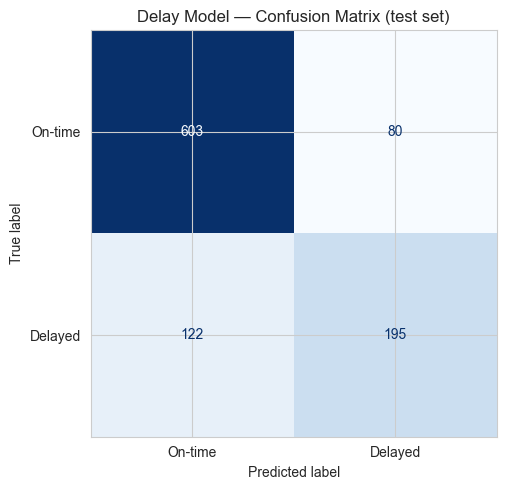

Delay Model — Classification Report:
              precision    recall  f1-score   support

     On-time       0.83      0.88      0.86       683
     Delayed       0.71      0.62      0.66       317

    accuracy                           0.80      1000
   macro avg       0.77      0.75      0.76      1000
weighted avg       0.79      0.80      0.79      1000



In [6]:
from sklearn.metrics import (confusion_matrix, classification_report,
                             roc_auc_score, ConfusionMatrixDisplay)

cm = confusion_matrix(y_delay_test, delay_pred)
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay(cm, display_labels=["On-time", "Delayed"]).plot(
    ax=ax, cmap="Blues", colorbar=False)
ax.set_title("Delay Model — Confusion Matrix (test set)")
plt.tight_layout()
plt.show()

print("Delay Model — Classification Report:")
print(classification_report(y_delay_test, delay_pred,
                            target_names=["On-time", "Delayed"]))

In [7]:
auc = roc_auc_score(y_delay_test, delay_proba)
print(f"Delay Model ROC-AUC: {auc:.3f}")
print()
print("ROC-AUC scale:  0.50 = random  |  0.70 = decent  |  0.80 = good  |  0.90+ = excellent")

Delay Model ROC-AUC: 0.855

ROC-AUC scale:  0.50 = random  |  0.70 = decent  |  0.80 = good  |  0.90+ = excellent


In [8]:
# Train the RETURN model — same XGBoost setup, different target
return_model = xgb.XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.1,
    random_state=42,
    eval_metric="logloss",
)

return_model.fit(X_train, y_return_train)
print("Return model trained on 4000 orders.")

return_pred = return_model.predict(X_test)
return_proba = return_model.predict_proba(X_test)[:, 1]
print(f"Predicted on {len(X_test)} unseen test orders.")

Return model trained on 4000 orders.
Predicted on 1000 unseen test orders.


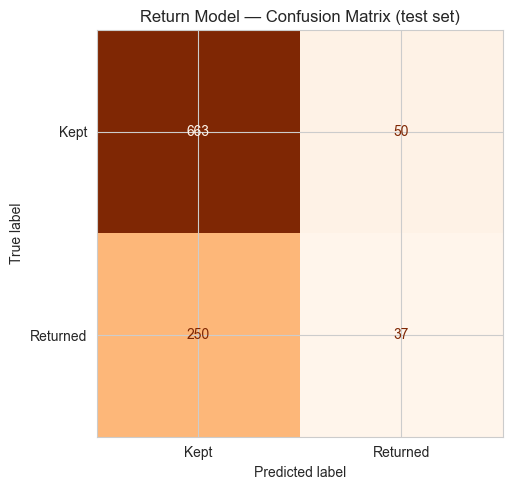

Return Model — Classification Report:
              precision    recall  f1-score   support

        Kept       0.73      0.93      0.82       713
    Returned       0.43      0.13      0.20       287

    accuracy                           0.70      1000
   macro avg       0.58      0.53      0.51      1000
weighted avg       0.64      0.70      0.64      1000



In [9]:
cm_r = confusion_matrix(y_return_test, return_pred)
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay(cm_r, display_labels=["Kept", "Returned"]).plot(
    ax=ax, cmap="Oranges", colorbar=False)
ax.set_title("Return Model — Confusion Matrix (test set)")
plt.tight_layout()
plt.show()

print("Return Model — Classification Report:")
print(classification_report(y_return_test, return_pred,
                            target_names=["Kept", "Returned"]))

In [10]:
auc_r = roc_auc_score(y_return_test, return_proba)
print(f"Return Model ROC-AUC: {auc_r:.3f}")
print(f"Delay model AUC was 0.855 — return is expected to be lower.")

Return Model ROC-AUC: 0.578
Delay model AUC was 0.855 — return is expected to be lower.


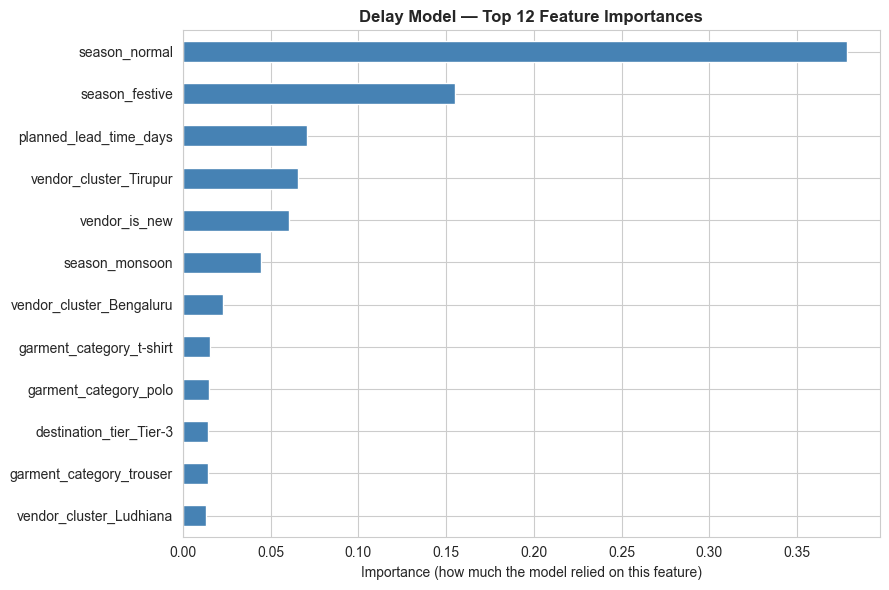

Top delay features:
season_normal               0.378
season_festive              0.155
planned_lead_time_days      0.071
vendor_cluster_Tirupur      0.066
vendor_is_new               0.060
season_monsoon              0.044
vendor_cluster_Bengaluru    0.023
garment_category_t-shirt    0.015
dtype: float32


In [11]:
# What did the DELAY model learn matters most?
delay_imp = pd.Series(delay_model.feature_importances_, index=X_train.columns)
delay_imp_top = delay_imp.sort_values(ascending=True).tail(12)

fig, ax = plt.subplots(figsize=(9, 6))
delay_imp_top.plot(kind="barh", ax=ax, color="steelblue")
ax.set_title("Delay Model — Top 12 Feature Importances", fontweight="bold")
ax.set_xlabel("Importance (how much the model relied on this feature)")
plt.tight_layout()
plt.show()

print("Top delay features:")
print(delay_imp.sort_values(ascending=False).head(8).round(3))

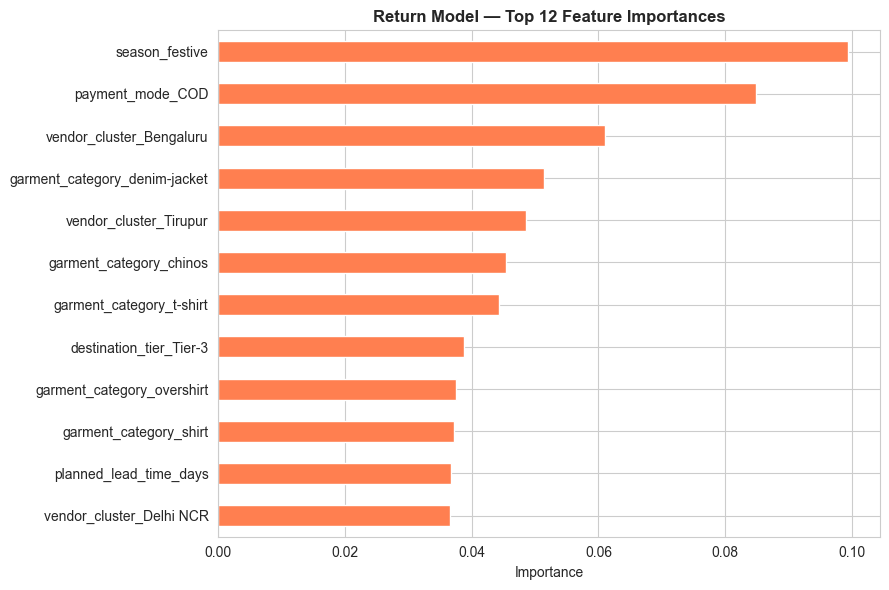

Top return features:
season_festive                   0.099
payment_mode_COD                 0.085
vendor_cluster_Bengaluru         0.061
garment_category_denim-jacket    0.051
vendor_cluster_Tirupur           0.049
garment_category_chinos          0.045
garment_category_t-shirt         0.044
destination_tier_Tier-3          0.039
dtype: float32


In [13]:
# What little signal did the RETURN model find?
return_imp = pd.Series(return_model.feature_importances_, index=X_train.columns)
return_imp_top = return_imp.sort_values(ascending=True).tail(12)

fig, ax = plt.subplots(figsize=(9, 6))
return_imp_top.plot(kind="barh", ax=ax, color="coral")
ax.set_title("Return Model — Top 12 Feature Importances", fontweight="bold")
ax.set_xlabel("Importance")
plt.tight_layout()
plt.show()

print("Top return features:")
print(return_imp.sort_values(ascending=False).head(8).round(3))

In [15]:
# The hybrid blends rule-based scores with ML probabilities.
# We work on the test set (1000 unseen orders) for an honest evaluation.

# ML probabilities for the test orders, scaled from 0-1 to 0-100
ml_delay_score  = delay_model.predict_proba(X_test)[:, 1] * 100
ml_return_score = return_model.predict_proba(X_test)[:, 1] * 100

# Rule-based scores for the SAME test orders — aligned by row index
rule_delay_score  = df.loc[X_test.index, "delay_score"].values
rule_return_score = df.loc[X_test.index, "return_score"].values

print("Test-set scores assembled:")
print(f"  Rule delay  mean: {rule_delay_score.mean():.1f}")
print(f"  ML delay    mean: {ml_delay_score.mean():.1f}")
print(f"  Rule return mean: {rule_return_score.mean():.1f}")
print(f"  ML return   mean: {ml_return_score.mean():.1f}")

Test-set scores assembled:
  Rule delay  mean: 36.6
  ML delay    mean: 31.1
  Rule return mean: 48.4
  ML return   mean: 29.7


In [16]:
# Hybrid = a simple 50/50 blend of rule and ML
hybrid_delay  = 0.5 * rule_delay_score  + 0.5 * ml_delay_score
hybrid_return = 0.5 * rule_return_score + 0.5 * ml_return_score

print("DELAY — ROC-AUC comparison (test set):")
print(f"  Rule scorer alone: {roc_auc_score(y_delay_test, rule_delay_score):.3f}")
print(f"  ML model alone:    {roc_auc_score(y_delay_test, ml_delay_score):.3f}")
print(f"  Hybrid (50/50):    {roc_auc_score(y_delay_test, hybrid_delay):.3f}")
print()
print("RETURN — ROC-AUC comparison (test set):")
print(f"  Rule scorer alone: {roc_auc_score(y_return_test, rule_return_score):.3f}")
print(f"  ML model alone:    {roc_auc_score(y_return_test, ml_return_score):.3f}")
print(f"  Hybrid (50/50):    {roc_auc_score(y_return_test, hybrid_return):.3f}")

DELAY — ROC-AUC comparison (test set):
  Rule scorer alone: 0.804
  ML model alone:    0.855
  Hybrid (50/50):    0.852

RETURN — ROC-AUC comparison (test set):
  Rule scorer alone: 0.624
  ML model alone:    0.578
  Hybrid (50/50):    0.620


In [17]:
# When rule and ML agree, confidence is high. When they disagree sharply,
# the order should go to a human. This is what two brains buys you.
delay_gap = abs(rule_delay_score - ml_delay_score)
disagree = delay_gap > 30   # scores more than 30 points apart

print(f"Rule and ML agree closely:  {(~disagree).sum()} orders ({(~disagree).mean()*100:.0f}%)")
print(f"Sharp disagreement (review): {disagree.sum()} orders ({disagree.mean()*100:.0f}%)")
print()
print("Agreement -> trust the score. Disagreement -> a human should look closer.")

Rule and ML agree closely:  837 orders (84%)
Sharp disagreement (review): 163 orders (16%)

Agreement -> trust the score. Disagreement -> a human should look closer.


In [18]:
# A 50/50 blend diluted the stronger model. Weight toward the better
# method per target: delay leans on ML, return leans on the rule scorer.
w_hybrid_delay  = 0.7 * ml_delay_score    + 0.3 * rule_delay_score
w_hybrid_return = 0.7 * rule_return_score + 0.3 * ml_return_score

print("Performance-weighted hybrid:")
print(f"  Delay  AUC: {roc_auc_score(y_delay_test, w_hybrid_delay):.3f}   (best single was 0.855)")
print(f"  Return AUC: {roc_auc_score(y_return_test, w_hybrid_return):.3f}   (best single was 0.624)")

Performance-weighted hybrid:
  Delay  AUC: 0.854   (best single was 0.855)
  Return AUC: 0.624   (best single was 0.624)
